In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from skimage.feature import graycomatrix, graycoprops

import warnings
warnings.filterwarnings("ignore")

## Import Library

Tahap ini bertujuan untuk mempersiapkan seluruh library yang digunakan dalam proses pengolahan citra, ekstraksi fitur tekstur, visualisasi data, serta klasifikasi penyakit daun jagung.

### Library yang Digunakan

| No | Library | Keterangan |
|----|---------|------------|
| 1 | `os` | Mengakses direktori dan mengelola file dataset. |
| 2 | `cv2` | Membaca, memproses, dan melakukan transformasi pada citra digital menggunakan OpenCV. |
| 3 | `numpy (np)` | Melakukan operasi komputasi numerik dan manipulasi array multidimensi. |
| 4 | `pandas (pd)` | Mengelola dan menganalisis data dalam bentuk DataFrame. |
| 5 | `matplotlib.pyplot (plt)` | Menampilkan visualisasi gambar dan grafik hasil analisis. |
| 6 | `seaborn (sns)` | Membuat visualisasi statistik seperti heatmap dan grafik distribusi data. |
| 7 | `train_test_split()` | Membagi dataset menjadi data pelatihan dan data pengujian. |
| 8 | `LabelEncoder()` | Mengubah label kategori menjadi representasi numerik. |
| 9 | `StandardScaler()` | Melakukan normalisasi fitur agar memiliki skala yang seragam. |
| 10 | `accuracy_score()` | Menghitung tingkat akurasi model klasifikasi. |
| 11 | `classification_report()` | Menampilkan nilai precision, recall, f1-score, dan support. |
| 12 | `confusion_matrix()` | Membentuk matriks evaluasi berdasarkan hasil prediksi model. |
| 13 | `KNeighborsClassifier()` | Membangun model klasifikasi K-Nearest Neighbors (KNN). |
| 14 | `SVC()` | Membangun model klasifikasi Support Vector Machine (SVM). |
| 15 | `RandomForestClassifier()` | Membangun model klasifikasi Random Forest. |
| 16 | `graycomatrix()` | Membentuk Gray Level Co-occurrence Matrix (GLCM) untuk ekstraksi fitur tekstur. |
| 17 | `graycoprops()` | Menghitung karakteristik tekstur dari matriks GLCM. |
| 18 | `warnings.filterwarnings()` | Menyembunyikan pesan warning agar output notebook lebih rapi. |

### Mengapa Library Ini Digunakan?

- Mendukung proses pengolahan citra mulai dari pembacaan hingga preprocessing.
- Memudahkan ekstraksi fitur tekstur menggunakan metode Gray Level Co-occurrence Matrix (GLCM).
- Menyediakan algoritma machine learning untuk proses klasifikasi.
- Menampilkan hasil analisis dan evaluasi model dalam bentuk visualisasi maupun tabel.

### Hasil

Seluruh library berhasil diimpor dan siap digunakan pada tahapan preprocessing citra, ekstraksi fitur GLCM, pembentukan dataset fitur, pelatihan model klasifikasi, serta evaluasi performa model.

In [8]:
dataset_path = "./dataset"

classes = [
    "Blight",
    "Common_Rust",
    "Gray_Leaf_Spot",
    "Healthy"
]

data = []
labels = []
file_names = []

img_size = (256, 256)

for label in classes:

    folder_path = os.path.join(dataset_path, label)

    for filename in os.listdir(folder_path):

        img_path = os.path.join(folder_path, filename)

        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, img_size)

        data.append(img)
        labels.append(label)
        file_names.append(filename)

print("Jumlah gambar :", len(data))

Jumlah gambar : 400


## Load Dataset

Tahap ini bertujuan untuk membaca seluruh citra daun jagung dari setiap kelas penyakit yang tersedia pada dataset. Setiap citra yang berhasil dibaca akan disimpan ke dalam variabel untuk digunakan pada proses preprocessing dan ekstraksi fitur.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `os.path.join()` | Menggabungkan path folder dan nama file. |
| `os.listdir()` | Menampilkan seluruh file yang terdapat dalam folder. |
| `cv2.imread()` | Membaca citra dari direktori penyimpanan. |
| `cv2.resize()` | Menyamakan ukuran seluruh citra menjadi 256×256 piksel. |
| `append()` | Menyimpan data citra, label, dan nama file ke dalam list. |

### Cara Kerja

- Dataset dibagi menjadi empat kelas, yaitu **Blight**, **Common Rust**, **Gray Leaf Spot**, dan **Healthy**.
- `os.listdir()` digunakan untuk membaca seluruh file pada masing-masing folder kelas.
- `cv2.imread()` membaca setiap citra yang ditemukan.
- `cv2.resize()` mengubah ukuran citra menjadi **256 × 256 piksel** agar seluruh data memiliki dimensi yang sama.
- Citra yang berhasil dibaca disimpan ke dalam `data`.
- Nama kelas disimpan ke dalam `labels`.
- Nama file citra disimpan ke dalam `file_names`.
- Citra yang gagal dibaca (`None`) akan dilewati.

### Mengapa Digunakan?

- Memastikan seluruh citra memiliki ukuran yang seragam sebelum diproses lebih lanjut.
- Mempermudah pengelompokan data berdasarkan kelas penyakit.
- Menyiapkan data citra beserta label yang diperlukan pada proses klasifikasi.

### Hasil

Seluruh citra dari empat kelas berhasil dimuat ke dalam memori dan disimpan pada variabel `data`, `labels`, dan `file_names`. Jumlah citra yang berhasil dibaca ditampilkan menggunakan `print("Jumlah gambar :", len(data))` sebagai verifikasi bahwa proses pemuatan dataset berjalan dengan baik.

In [9]:
df = pd.DataFrame({
    "filename": file_names,
    "label": labels
})

df["label"].value_counts()

label
Blight            100
Common_Rust       100
Gray_Leaf_Spot    100
Healthy           100
Name: count, dtype: int64

## Data Understanding

Tahap ini bertujuan untuk mengetahui distribusi jumlah citra pada setiap kelas penyakit daun jagung sebelum dilakukan proses preprocessing dan ekstraksi fitur.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `pd.DataFrame()` | Membentuk data tabular yang berisi nama file dan label kelas. |
| `value_counts()` | Menghitung jumlah data pada setiap kelas. |

### Cara Kerja

- `pd.DataFrame()` digunakan untuk menggabungkan `file_names` dan `labels` ke dalam satu tabel.
- Kolom `filename` berisi nama file citra.
- Kolom `label` berisi kelas penyakit dari setiap citra.
- `value_counts()` menghitung jumlah citra pada masing-masing kelas.
- Hasil perhitungan ditampilkan dalam bentuk tabel distribusi kelas.

### Mengapa Digunakan?

- Memastikan seluruh kelas berhasil dimuat dari dataset.
- Mengetahui keseimbangan jumlah data pada setiap kelas.
- Mengidentifikasi kemungkinan ketidakseimbangan data yang dapat memengaruhi performa model klasifikasi.

### Hasil

Distribusi jumlah citra pada setiap kelas berhasil ditampilkan. Hasil ini digunakan untuk memastikan bahwa dataset memiliki jumlah data yang memadai dan representatif sebelum memasuki tahap preprocessing, ekstraksi fitur GLCM, serta proses klasifikasi menggunakan KNN, SVM, dan Random Forest.

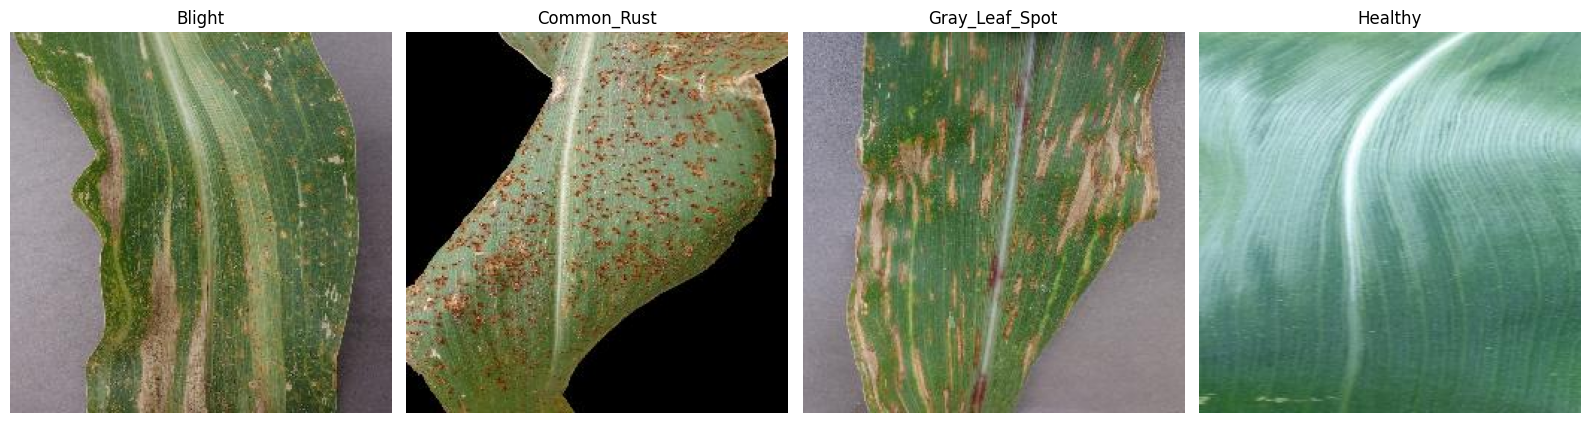

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for i, kelas in enumerate(classes):

    idx = labels.index(kelas)

    img_rgb = cv2.cvtColor(data[idx], cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(kelas)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Visualisasi Sampel Dataset

Tahap ini bertujuan untuk menampilkan contoh citra dari setiap kelas penyakit daun jagung sehingga karakteristik visual masing-masing kelas dapat diamati sebelum dilakukan proses preprocessing dan ekstraksi fitur.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `cv2.cvtColor()` | Mengubah format warna citra dari BGR menjadi RGB agar warna tampil sesuai saat divisualisasikan. |
| `imshow()` | Menampilkan citra sampel dari setiap kelas. |

### Cara Kerja

- Satu citra dipilih sebagai perwakilan dari masing-masing kelas.
- Sampel citra ditampilkan untuk kelas **Blight**, **Common Rust**, **Gray Leaf Spot**, dan **Healthy**.
- Warna citra disesuaikan agar sesuai dengan tampilan aslinya sebelum divisualisasikan.

### Mengapa Digunakan?

- Memberikan gambaran awal mengenai karakteristik visual setiap kelas penyakit.
- Membantu mengidentifikasi perbedaan kondisi daun sehat dan daun yang terinfeksi penyakit.
- Memastikan citra berhasil dimuat dengan benar sebelum memasuki tahap preprocessing.
- Menjadi dasar observasi sebelum dilakukan ekstraksi fitur tekstur menggunakan GLCM.

### Hasil

Sampel citra dari setiap kelas berhasil ditampilkan. Visualisasi menunjukkan adanya perbedaan pola warna, bentuk bercak, dan kondisi permukaan daun pada masing-masing kelas yang nantinya akan dianalisis lebih lanjut melalui proses ekstraksi fitur.

In [11]:
for i in range(len(data)):
    data[i] = cv2.cvtColor(data[i], cv2.COLOR_BGR2GRAY)

## Konversi Grayscale

Tahap ini bertujuan untuk mengubah citra berwarna menjadi citra grayscale sebelum dilakukan proses filtering, deteksi tepi, dan ekstraksi fitur tekstur.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `cv2.cvtColor()` | Mengubah citra dari format BGR menjadi grayscale. |

### Cara Kerja

- Setiap citra pada dataset diproses secara berulang menggunakan perulangan.
- `cv2.cvtColor()` mengubah citra berwarna menjadi citra grayscale.
- Hasil konversi menggantikan citra sebelumnya pada variabel `data`.
- Setiap piksel direpresentasikan oleh satu nilai intensitas keabuan.

### Mengapa Digunakan?

- Mengurangi kompleksitas data citra dengan menghilangkan informasi warna.
- Memfokuskan analisis pada pola intensitas dan tekstur citra.
- Mempercepat proses komputasi dibandingkan menggunakan citra berwarna.
- Menyesuaikan format citra dengan kebutuhan ekstraksi fitur GLCM yang bekerja pada citra grayscale.

### Hasil

Seluruh citra berhasil dikonversi menjadi grayscale sehingga setiap citra hanya memiliki satu kanal intensitas. Hasil konversi ini digunakan sebagai masukan pada tahap preprocessing dan ekstraksi fitur tekstur berikutnya.

In [12]:
def median_filter(img, size=3):

    h, w = img.shape
    pad = size // 2

    padded = np.pad(img, pad, mode='edge')
    hasil = np.zeros_like(img)

    for i in range(h):
        for j in range(w):

            region = padded[i:i+size, j:j+size]

            nilai = np.sort(region.flatten())

            hasil[i, j] = nilai[len(nilai)//2]

    return hasil

median_data = []

for img in data:

    median = median_filter(img, 3)

    median_data.append(median)

## Median Filter

Tahap ini bertujuan untuk mengurangi noise pada citra grayscale sebelum dilakukan proses deteksi tepi dan ekstraksi fitur tekstur. Proses filtering dilakukan secara manual menggunakan kernel berukuran 3×3.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `np.pad()` | Menambahkan padding pada tepi citra agar seluruh piksel dapat diproses. |
| `flatten()` | Mengubah matriks kernel menjadi array satu dimensi. |
| `np.sort()` | Mengurutkan nilai piksel pada area kernel. |
| `np.zeros_like()` | Membuat matriks kosong dengan ukuran yang sama seperti citra asli. |
| `append()` | Menyimpan hasil filtering ke dalam `median_data`. |

### Cara Kerja

- Setiap citra grayscale diproses menggunakan kernel berukuran 3×3.
- Area piksel di sekitar piksel pusat diambil sebagai region pengamatan.
- Seluruh nilai piksel pada region tersebut diurutkan menggunakan `np.sort()`.
- Nilai median dipilih sebagai pengganti nilai piksel pusat.
- Proses dilakukan untuk seluruh piksel pada citra.
- Hasil filtering disimpan ke dalam `median_data`.

### Mengapa Digunakan?

- Mengurangi noise yang dapat mengganggu proses deteksi tepi.
- Mempertahankan detail objek lebih baik dibandingkan filter rata-rata.
- Mengurangi pengaruh piksel ekstrem yang muncul akibat gangguan pada citra.
- Membantu menghasilkan pola tekstur yang lebih stabil sebelum proses ekstraksi fitur GLCM.

### Hasil

Seluruh citra grayscale berhasil diproses menggunakan Median Filter. Hasil filtering memiliki tingkat noise yang lebih rendah sehingga struktur objek daun menjadi lebih jelas dan siap digunakan pada tahap deteksi tepi menggunakan operator Sobel dan Robert.

In [13]:
def convolution(img, kernel):

    size = kernel.shape[0]
    pad = size // 2

    padded = np.pad(img, pad, mode='constant')
    hasil = np.zeros_like(img, dtype=np.float32)

    h, w = img.shape

    for i in range(h):
        for j in range(w):

            region = padded[i:i+size, j:j+size]

            hasil[i, j] = np.sum(region * kernel)

    return hasil

## Konvolusi

Tahap ini bertujuan untuk menerapkan operasi konvolusi yang digunakan sebagai dasar dalam proses deteksi tepi. Hasil konvolusi diperoleh dengan mengalikan nilai piksel pada citra dengan nilai kernel, kemudian menjumlahkan seluruh hasil perkalian tersebut.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `np.pad()` | Menambahkan padding pada tepi citra agar seluruh piksel dapat diproses. |
| `np.zeros_like()` | Membuat matriks kosong untuk menyimpan hasil konvolusi. |
| `np.sum()` | Menjumlahkan hasil perkalian antara region citra dan kernel. |

### Cara Kerja

- Kernel yang digunakan diterima melalui parameter `kernel`.
- Padding ditambahkan pada tepi citra untuk mengatasi piksel di bagian batas.
- Area citra yang sesuai dengan ukuran kernel diambil secara bergeser pada setiap piksel.
- Nilai piksel pada area tersebut dikalikan dengan nilai kernel.
- Hasil perkalian dijumlahkan menggunakan `np.sum()`.
- Nilai hasil konvolusi disimpan pada posisi piksel yang bersesuaian.

### Mengapa Digunakan?

- Menjadi dasar utama dalam proses deteksi tepi menggunakan operator Sobel dan Robert.
- Memungkinkan penerapan berbagai kernel pengolahan citra pada fungsi yang sama.
- Membantu menonjolkan perubahan intensitas piksel yang menunjukkan keberadaan tepi objek.
- Menghasilkan citra yang lebih informatif untuk proses analisis tekstur berikutnya.

### Hasil

Fungsi konvolusi berhasil dibentuk dan digunakan sebagai komponen utama dalam proses deteksi tepi. Hasil dari fungsi ini akan digunakan pada tahap Sobel dan Robert untuk memperoleh informasi batas objek pada citra daun jagung.

In [14]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobel_y = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)

In [15]:
def sobel_edge(img):

    gx = convolution(img, sobel_x)
    gy = convolution(img, sobel_y)

    hasil = np.abs(gx) + np.abs(gy)

    hasil = hasil * 255 / np.max(hasil)

    return hasil.astype(np.uint8)

In [16]:
sobel_data = []

for img in median_data:

    sobel = sobel_edge(img)

    sobel_data.append(sobel)

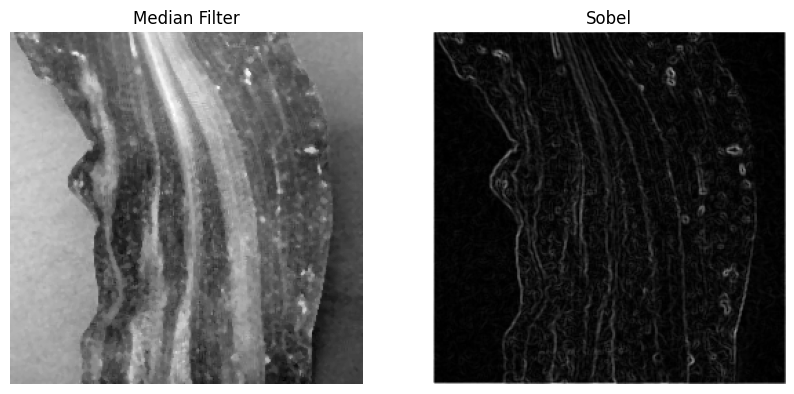

In [17]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(median_data[0], cmap='gray')
plt.title("Median Filter")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sobel_data[0], cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.show()

## Deteksi Tepi Sobel

Tahap ini bertujuan untuk menonjolkan batas objek pada citra daun menggunakan operator Sobel. Deteksi tepi dilakukan setelah proses Median Filter sehingga pengaruh noise dapat dikurangi terlebih dahulu.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `convolution()` | Menerapkan operasi konvolusi antara citra dan kernel Sobel. |
| `np.array()` | Membentuk kernel Sobel arah horizontal dan vertikal. |
| `np.abs()` | Mengubah nilai gradien menjadi nilai absolut. |
| `np.max()` | Mencari nilai maksimum untuk proses normalisasi. |
| `append()` | Menyimpan hasil deteksi tepi ke dalam `sobel_data`. |

### Cara Kerja

- Kernel Sobel horizontal (`sobel_x`) digunakan untuk mendeteksi perubahan intensitas pada arah horizontal.
- Kernel Sobel vertikal (`sobel_y`) digunakan untuk mendeteksi perubahan intensitas pada arah vertikal.
- `convolution()` diterapkan menggunakan kedua kernel untuk memperoleh nilai gradien horizontal dan vertikal.
- Nilai gradien digabungkan menggunakan penjumlahan nilai absolut kedua arah.
- Hasil gradien dinormalisasi ke rentang 0–255 agar dapat direpresentasikan sebagai citra grayscale.
- Seluruh citra hasil Median Filter diproses dan disimpan ke dalam `sobel_data`.

### Mengapa Digunakan?

- Menonjolkan batas objek daun dan area bercak penyakit.
- Mengidentifikasi perubahan intensitas yang menunjukkan keberadaan tepi.
- Membantu memperjelas pola tekstur sebelum dilakukan ekstraksi fitur.
- Mengurangi pengaruh area homogen yang kurang memberikan informasi penting.

### Hasil

Seluruh citra berhasil diproses menggunakan operator Sobel sehingga diperoleh citra tepi yang menampilkan perubahan intensitas pada objek daun. Hasil ini digunakan sebagai salah satu sumber informasi tekstur pada tahap berikutnya.

In [18]:
robert_x = np.array([
    [1, 0],
    [0,-1]
], dtype=np.float32)

robert_y = np.array([
    [0, 1],
    [-1,0]
], dtype=np.float32)

In [19]:
def robert_edge(img):

    gx = convolution(img, robert_x)
    gy = convolution(img, robert_y)

    hasil = np.abs(gx) + np.abs(gy)

    hasil = hasil * 255 / np.max(hasil)

    return hasil.astype(np.uint8)

In [20]:
robert_data = []

for img in median_data:

    robert = robert_edge(img)

    robert_data.append(robert)

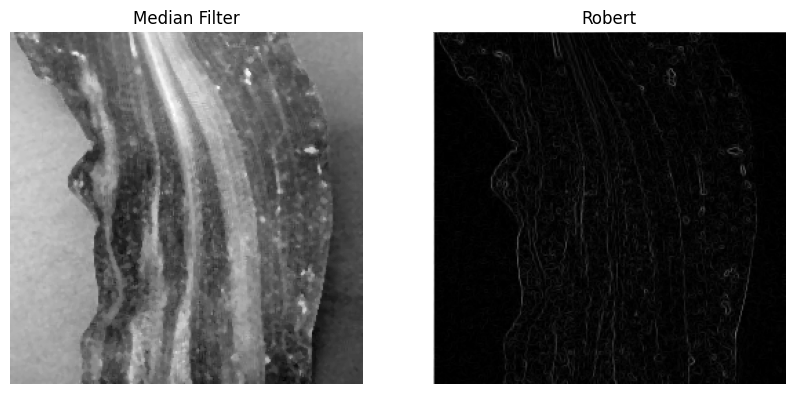

In [21]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(median_data[0], cmap='gray')
plt.title("Median Filter")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(robert_data[0], cmap='gray')
plt.title("Robert")
plt.axis('off')

plt.show()

## Deteksi Tepi Robert

Tahap ini bertujuan untuk menonjolkan batas objek pada citra menggunakan operator Robert. Operator ini mendeteksi perubahan intensitas piksel berdasarkan perbedaan diagonal sehingga mampu menghasilkan tepi yang lebih tajam pada area tertentu.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `convolution()` | Menerapkan operasi konvolusi antara citra dan kernel Robert. |
| `np.array()` | Membentuk kernel Robert untuk arah diagonal. |
| `np.abs()` | Mengubah nilai gradien menjadi nilai absolut. |
| `np.max()` | Mencari nilai maksimum untuk proses normalisasi. |
| `append()` | Menyimpan hasil deteksi tepi ke dalam `robert_data`. |

### Cara Kerja

- Kernel Robert horizontal (`robert_x`) digunakan untuk mendeteksi perubahan intensitas pada salah satu arah diagonal.
- Kernel Robert vertikal (`robert_y`) digunakan untuk mendeteksi perubahan intensitas pada arah diagonal lainnya.
- `convolution()` diterapkan menggunakan kedua kernel untuk memperoleh nilai gradien.
- Nilai gradien dari kedua arah digabungkan menggunakan penjumlahan nilai absolut.
- Hasil gradien dinormalisasi ke rentang 0–255 agar dapat direpresentasikan sebagai citra grayscale.
- Seluruh citra hasil Median Filter diproses dan disimpan ke dalam `robert_data`.

### Mengapa Digunakan?

- Menonjolkan batas objek dan area penyakit berdasarkan perubahan intensitas piksel.
- Mampu mendeteksi detail tepi yang halus karena menggunakan kernel berukuran 2×2.
- Melengkapi informasi tepi yang diperoleh dari operator Sobel.
- Membantu menghasilkan representasi tekstur yang lebih kaya sebelum proses ekstraksi fitur.

### Hasil

Seluruh citra berhasil diproses menggunakan operator Robert sehingga diperoleh citra tepi yang menampilkan perubahan intensitas pada objek daun. Hasil deteksi tepi ini digunakan sebagai salah satu sumber informasi tekstur pada tahap selanjutnya.

In [22]:
combined_data = []

for i in range(len(sobel_data)):

    gabung = np.maximum(
        sobel_data[i],
        robert_data[i]
    )

    combined_data.append(gabung)

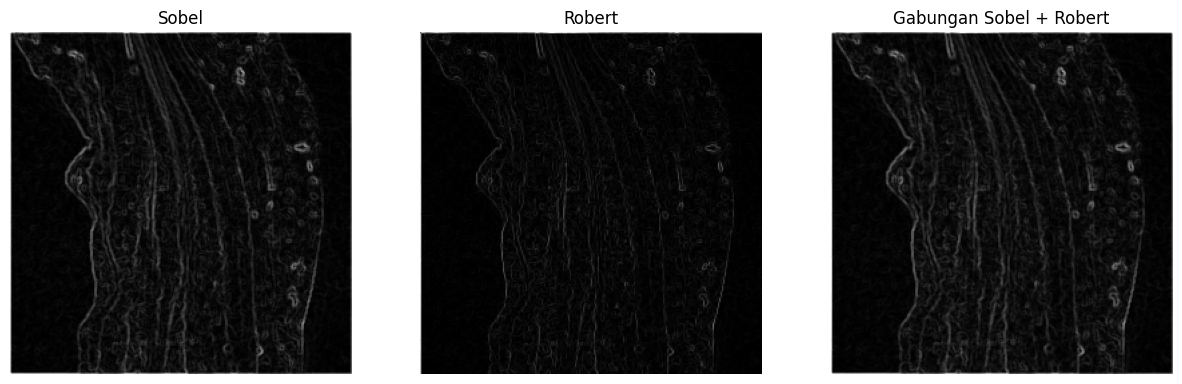

In [23]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(sobel_data[0], cmap='gray')
plt.title("Sobel")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(robert_data[0], cmap='gray')
plt.title("Robert")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(combined_data[0], cmap='gray')
plt.title("Gabungan Sobel + Robert")
plt.axis('off')

plt.show()

## Penggabungan Hasil Sobel dan Robert

Tahap ini bertujuan untuk menggabungkan informasi tepi yang diperoleh dari operator Sobel dan Robert sehingga karakteristik batas objek dapat ditampilkan secara lebih lengkap.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `np.maximum()` | Memilih nilai piksel terbesar dari hasil Sobel dan Robert pada posisi yang sama. |
| `append()` | Menyimpan hasil penggabungan ke dalam `combined_data`. |

### Cara Kerja

- Setiap citra hasil Sobel dipasangkan dengan citra hasil Robert yang memiliki indeks yang sama.
- `np.maximum()` digunakan untuk membandingkan nilai piksel dari kedua citra.
- Nilai terbesar pada setiap posisi piksel dipilih sebagai hasil akhir.
- Hasil penggabungan disimpan ke dalam `combined_data`.

### Mengapa Digunakan?

- Menggabungkan informasi tepi yang diperoleh dari dua operator berbeda.
- Mempertahankan tepi yang terdeteksi kuat oleh Sobel maupun Robert.
- Mengurangi kemungkinan hilangnya informasi batas objek.
- Menghasilkan representasi tepi yang lebih lengkap dibandingkan menggunakan satu operator saja.

### Hasil

Citra hasil penggabungan menampilkan tepi objek daun dengan lebih jelas karena mengakomodasi informasi yang diperoleh dari operator Sobel dan Robert. Area tepi yang sebelumnya hanya terdeteksi oleh salah satu operator dapat muncul lebih kuat pada citra hasil gabungan. Selain itu, bentuk daun, pola bercak penyakit, serta batas antar area pada permukaan daun terlihat lebih tegas dibandingkan hasil deteksi tepi secara terpisah.

In [24]:
def glcm(image, derajat):

    return graycomatrix(
        image,
        distances=[1],
        angles=[derajat],
        levels=256,
        symmetric=True,
        normed=True
    )

In [25]:
def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0,0]

def homogeneity(matriks):
    return graycoprops(matriks, 'homogeneity')[0,0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0,0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0,0]

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0,0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0,0]

def entropyGlcm(matriks):
    return -np.sum(matriks * np.log2(matriks + 1e-10))

In [26]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(combined_data)):

    D0 = glcm(combined_data[i], 0)
    D45 = glcm(combined_data[i], np.pi/4)
    D90 = glcm(combined_data[i], np.pi/2)
    D135 = glcm(combined_data[i], 3*np.pi/4)

    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [27]:
contrast0 = []
contrast45 = []
contrast90 = []
contrast135 = []

for i in range(len(combined_data)):

    contrast0.append(
        contrast(Derajat0[i])
    )

    contrast45.append(
        contrast(Derajat45[i])
    )

    contrast90.append(
        contrast(Derajat90[i])
    )

    contrast135.append(
        contrast(Derajat135[i])
    )

In [28]:
homogeneity0 = []
homogeneity45 = []
homogeneity90 = []
homogeneity135 = []

for i in range(len(combined_data)):

    homogeneity0.append(
        homogeneity(Derajat0[i])
    )

    homogeneity45.append(
        homogeneity(Derajat45[i])
    )

    homogeneity90.append(
        homogeneity(Derajat90[i])
    )

    homogeneity135.append(
        homogeneity(Derajat135[i])
    )

In [29]:
dissimilarity0 = []
dissimilarity45 = []
dissimilarity90 = []
dissimilarity135 = []

for i in range(len(combined_data)):

    dissimilarity0.append(
        dissimilarity(Derajat0[i])
    )

    dissimilarity45.append(
        dissimilarity(Derajat45[i])
    )

    dissimilarity90.append(
        dissimilarity(Derajat90[i])
    )

    dissimilarity135.append(
        dissimilarity(Derajat135[i])
    )

In [30]:
energy0 = []
energy45 = []
energy90 = []
energy135 = []

for i in range(len(combined_data)):

    energy0.append(
        energy(Derajat0[i])
    )

    energy45.append(
        energy(Derajat45[i])
    )

    energy90.append(
        energy(Derajat90[i])
    )

    energy135.append(
        energy(Derajat135[i])
    )

In [31]:
correlation0 = []
correlation45 = []
correlation90 = []
correlation135 = []

for i in range(len(combined_data)):

    correlation0.append(
        correlation(Derajat0[i])
    )

    correlation45.append(
        correlation(Derajat45[i])
    )

    correlation90.append(
        correlation(Derajat90[i])
    )

    correlation135.append(
        correlation(Derajat135[i])
    )

In [32]:
entropy0 = []
entropy45 = []
entropy90 = []
entropy135 = []

for i in range(len(combined_data)):

    entropy0.append(
        entropyGlcm(Derajat0[i])
    )

    entropy45.append(
        entropyGlcm(Derajat45[i])
    )

    entropy90.append(
        entropyGlcm(Derajat90[i])
    )

    entropy135.append(
        entropyGlcm(Derajat135[i])
    )

In [33]:
asm0 = []
asm45 = []
asm90 = []
asm135 = []

for i in range(len(combined_data)):

    asm0.append(
        ASM(Derajat0[i])
    )

    asm45.append(
        ASM(Derajat45[i])
    )

    asm90.append(
        ASM(Derajat90[i])
    )

    asm135.append(
        ASM(Derajat135[i])
    )

In [34]:
hasilEkstrak = pd.DataFrame({

    'Filename': file_names,
    'Label': labels,

    'Contrast0': contrast0,
    'Contrast45': contrast45,
    'Contrast90': contrast90,
    'Contrast135': contrast135,

    'Homogeneity0': homogeneity0,
    'Homogeneity45': homogeneity45,
    'Homogeneity90': homogeneity90,
    'Homogeneity135': homogeneity135,

    'Dissimilarity0': dissimilarity0,
    'Dissimilarity45': dissimilarity45,
    'Dissimilarity90': dissimilarity90,
    'Dissimilarity135': dissimilarity135,

    'Energy0': energy0,
    'Energy45': energy45,
    'Energy90': energy90,
    'Energy135': energy135,

    'Correlation0': correlation0,
    'Correlation45': correlation45,
    'Correlation90': correlation90,
    'Correlation135': correlation135,

    'Entropy0': entropy0,
    'Entropy45': entropy45,
    'Entropy90': entropy90,
    'Entropy135': entropy135,

    'ASM0': asm0,
    'ASM45': asm45,
    'ASM90': asm90,
    'ASM135': asm135
})

hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Correlation90,Correlation135,Entropy0,Entropy45,Entropy90,Entropy135,ASM0,ASM45,ASM90,ASM135
0,Corn_Blight (1003).JPG,Blight,342.377298,497.785313,198.574862,524.285752,0.223021,0.195826,0.249189,0.186259,...,0.784521,0.282996,9.855876,9.957745,9.567918,10.046518,0.003230,0.002832,0.003596,0.002665
1,Corn_Blight (1004).JPG,Blight,337.897687,560.579808,253.288097,590.045644,0.331258,0.286543,0.346124,0.271430,...,0.747762,0.219947,8.683902,8.820415,8.467217,8.932945,0.009457,0.007827,0.009480,0.007403
2,Corn_Blight (1005).JPG,Blight,246.578033,387.169704,148.408287,376.751111,0.226829,0.192453,0.288462,0.200514,...,0.771526,0.230617,9.545038,9.690644,9.052608,9.625625,0.002971,0.002529,0.003794,0.002654
3,Corn_Blight (1010).JPG,Blight,212.379243,375.482199,171.267126,370.734610,0.316533,0.276653,0.353890,0.278247,...,0.721221,0.197061,8.611491,8.779667,8.323354,8.759615,0.006956,0.005869,0.007576,0.005859
4,Corn_Blight (1011).jpg,Blight,303.802175,437.464606,155.649786,440.976655,0.232446,0.203301,0.275504,0.206387,...,0.813328,0.350280,9.810374,9.944027,9.378771,9.938286,0.003330,0.002848,0.003891,0.002864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,Corn_Health (94).jpg,Healthy,142.027803,273.155909,129.079488,266.487920,0.358071,0.328281,0.566135,0.342910,...,0.735412,0.264837,7.777616,7.862978,6.748524,7.777774,0.011616,0.010736,0.021127,0.011322
396,Corn_Health (96).jpg,Healthy,195.891008,375.751034,182.114844,353.530119,0.326376,0.286788,0.362140,0.331500,...,0.706580,0.249067,8.146112,8.317062,7.912247,8.070323,0.009554,0.008246,0.010653,0.009505
397,Corn_Health (97).jpg,Healthy,168.626716,341.218947,166.001593,322.723660,0.385643,0.331854,0.469774,0.401399,...,0.701649,0.215183,7.337532,7.560469,6.914991,7.184787,0.016131,0.013797,0.020120,0.016828
398,Corn_Health (98).jpg,Healthy,239.223943,479.923629,237.755070,472.762768,0.435172,0.388010,0.521059,0.402324,...,0.674148,0.073215,7.053335,7.255264,6.623442,7.108347,0.018184,0.015780,0.022212,0.016280


## Ekstraksi Fitur GLCM

Tahap ini bertujuan untuk mengekstraksi karakteristik tekstur dari citra hasil penggabungan deteksi tepi menggunakan metode Gray Level Co-occurrence Matrix (GLCM). Fitur yang dihasilkan digunakan untuk merepresentasikan pola tekstur yang terdapat pada permukaan daun.

### Fungsi yang Digunakan

| Fungsi | Fitur | Deskripsi |
|---------|---------|------------|
| `graycomatrix()` | GLCM | Membentuk matriks hubungan antar piksel berdasarkan jarak dan orientasi tertentu. |
| `graycoprops(..., 'contrast')` | Contrast | Mengukur tingkat perbedaan intensitas antar piksel yang berdekatan. |
| `graycoprops(..., 'homogeneity')` | Homogeneity | Mengukur tingkat keseragaman distribusi piksel pada citra. |
| `graycoprops(..., 'dissimilarity')` | Dissimilarity | Mengukur tingkat ketidakmiripan antar pasangan piksel. |
| `graycoprops(..., 'energy')` | Energy | Mengukur tingkat keteraturan pola tekstur pada citra. |
| `graycoprops(..., 'correlation')` | Correlation | Mengukur hubungan linier antar pasangan piksel yang bertetangga. |
| `entropy()` | Entropy | Mengukur tingkat kompleksitas atau ketidakteraturan tekstur citra. |
| `ASM` | Angular Second Moment | Mengukur tingkat keseragaman energi pada matriks GLCM. |

### Cara Kerja

- Matriks GLCM dibentuk menggunakan jarak piksel 1 dengan empat orientasi sudut yaitu 0°, 45°, 90°, dan 135°.
- Setiap citra menghasilkan empat matriks GLCM yang merepresentasikan hubungan spasial piksel dari arah yang berbeda.
- Dari setiap matriks GLCM dihitung sejumlah fitur tekstur yang mewakili karakteristik citra.
- Fitur yang diekstraksi meliputi Contrast, Homogeneity, Dissimilarity, Energy, Correlation, Entropy, dan ASM.
- Proses ekstraksi dilakukan pada seluruh citra sehingga setiap citra memiliki kumpulan nilai fitur untuk keempat orientasi sudut.

### Mengapa Menggunakan GLCM?

- Mampu merepresentasikan pola tekstur berdasarkan hubungan antar piksel dalam citra.
- Menghasilkan fitur statistik yang dapat membedakan karakteristik antar kelas penyakit daun.
- Mampu menangkap informasi tekstur dari berbagai arah melalui penggunaan beberapa orientasi sudut.
- Mengubah informasi visual citra menjadi data numerik yang dapat dianalisis dan dibandingkan secara objektif.

### Hasil

Proses ekstraksi menghasilkan sekumpulan fitur tekstur yang menggambarkan karakteristik permukaan daun pada setiap citra. Nilai Contrast menunjukkan tingkat variasi intensitas, Homogeneity menunjukkan keseragaman tekstur, Dissimilarity menggambarkan perbedaan antar piksel, sedangkan Energy, ASM, Correlation, dan Entropy memberikan informasi mengenai keteraturan, hubungan antar piksel, serta kompleksitas tekstur citra. Perbedaan nilai fitur yang dihasilkan menunjukkan adanya karakteristik tekstur yang berbeda pada setiap kelas penyakit daun jagung.

In [36]:
hasilEkstrak = hasilEkstrak.sort_values(
    by="Label"
).reset_index(drop=True)

hasilEkstrak.to_csv(
    "hasil_ekstraksi_pros2.csv"
)

## Penyimpanan Hasil Ekstraksi

Tahap ini bertujuan untuk menyimpan seluruh fitur tekstur hasil ekstraksi GLCM ke dalam format CSV sehingga dapat digunakan untuk analisis dan dokumentasi.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `sort_values()` | Mengurutkan data berdasarkan label kelas. |
| `reset_index()` | Membuat ulang indeks setelah proses pengurutan. |
| `to_csv()` | Menyimpan data hasil ekstraksi ke dalam format CSV. |

### Cara Kerja

- Data hasil ekstraksi diurutkan berdasarkan label kelas.
- Indeks diperbarui setelah proses pengurutan.
- Seluruh data disimpan ke dalam file CSV.
- Setiap baris merepresentasikan satu citra beserta fitur teksturnya.

### Mengapa Dilakukan?

- Memudahkan dokumentasi hasil ekstraksi fitur.
- Menyimpan data dalam format yang ringan dan mudah dibaca.
- Memudahkan proses analisis dan verifikasi data.

### Hasil

Data hasil ekstraksi berhasil disimpan ke dalam file `hasil_ekstraksi_pros2.csv`. File tersebut berisi nama file, label kelas, serta seluruh fitur tekstur hasil ekstraksi GLCM untuk setiap citra daun jagung.

In [37]:
fitur = hasilEkstrak.drop(
    columns=['Filename', 'Label']
)

In [38]:
correlation = fitur.corr()

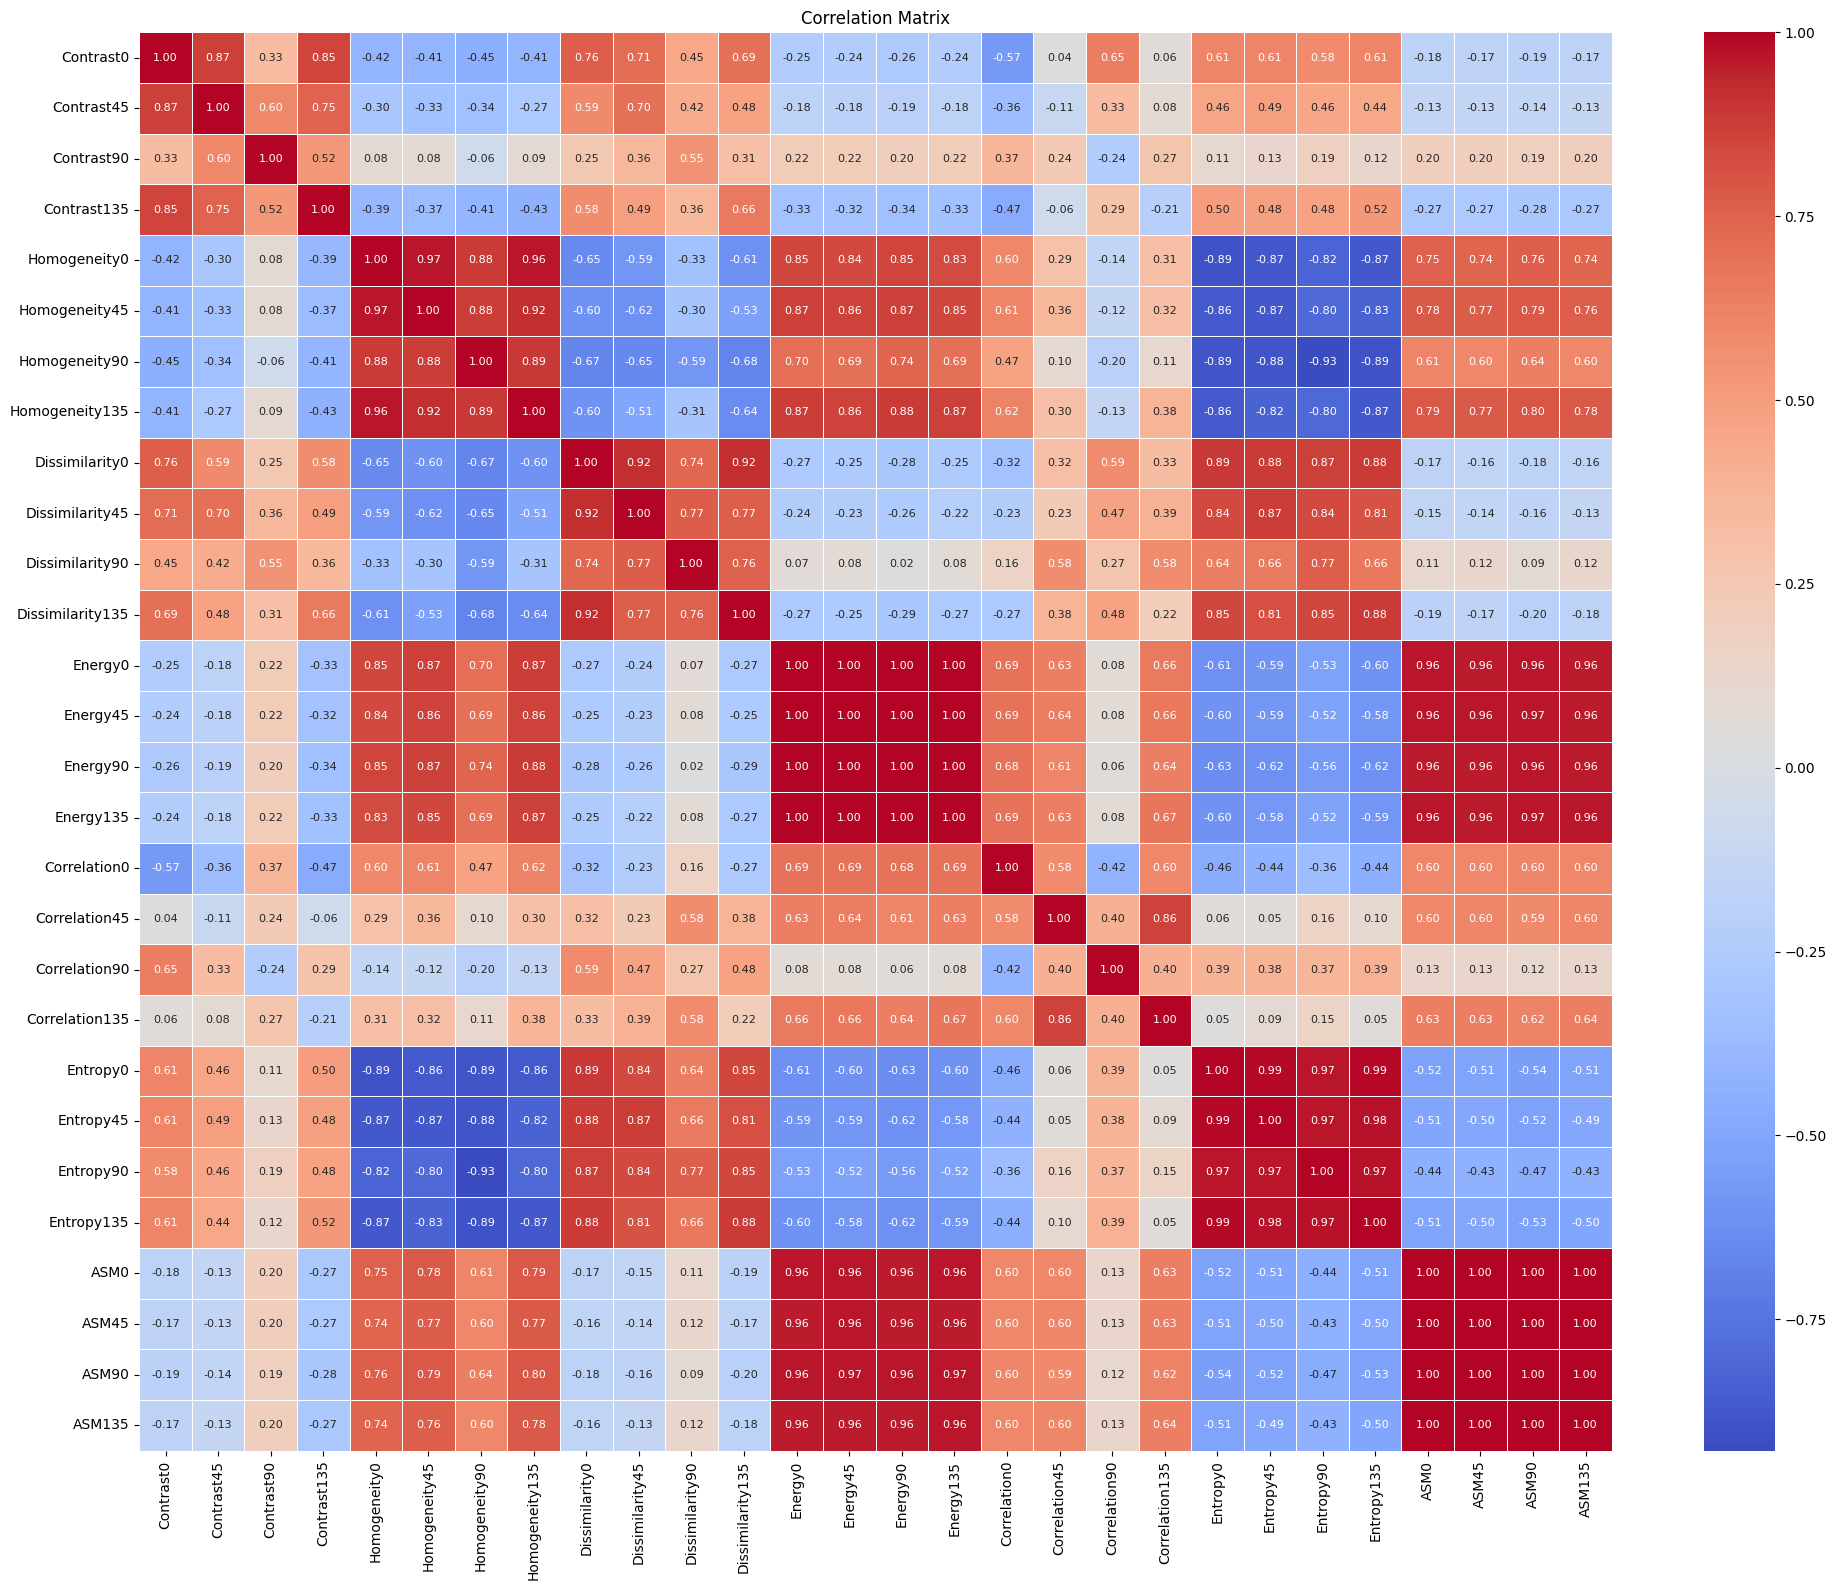

In [39]:
plt.figure(figsize=(20,16))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size":8},
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Analisis Korelasi Fitur

Tahap ini bertujuan untuk mengetahui hubungan antar fitur tekstur yang dihasilkan oleh metode GLCM.

### Fungsi yang Digunakan

| Fungsi | Keterangan |
|---------|------------|
| `drop()` | Menghapus kolom yang tidak digunakan dalam analisis korelasi. |
| `corr()` | Menghitung nilai korelasi antar fitur. |

### Cara Kerja

- Kolom `Filename` dan `Label` dikeluarkan dari data.
- Seluruh fitur numerik digunakan dalam perhitungan korelasi.
- Nilai korelasi dihitung untuk setiap pasangan fitur.
- Hasil perhitungan disimpan dalam bentuk matriks korelasi.

### Mengapa Dilakukan?

- Mengetahui hubungan antar fitur tekstur.
- Mengidentifikasi fitur yang memiliki keterkaitan sangat kuat.
- Membantu memahami karakteristik data hasil ekstraksi.

### Hasil

Matriks korelasi menunjukkan tingkat hubungan antar fitur GLCM. Nilai korelasi yang mendekati 1 menunjukkan hubungan positif yang kuat, nilai mendekati -1 menunjukkan hubungan negatif yang kuat, sedangkan nilai yang mendekati 0 menunjukkan hubungan yang lemah. Hasil ini memberikan gambaran mengenai keterkaitan antar karakteristik tekstur yang diekstraksi dari citra daun jagung.

In [40]:
X = hasilEkstrak.drop(
    columns=['Filename', 'Label']
)

y = hasilEkstrak['Label']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train,
    y_train
)

y_pred_knn = knn.predict(
    X_test
)

print("-----TRAINING-----")

y_train_pred_knn = knn.predict(X_train)

print(
    classification_report(
        y_train,
        y_train_pred_knn
    )
)

cm_train_knn = confusion_matrix(
    y_train,
    y_train_pred_knn
)

print(cm_train_knn)

print(
    "Accuracy Train :",
    accuracy_score(
        y_train,
        y_train_pred_knn
    )
)

print()
print("-----TESTING-----")

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

cm_test_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

print(cm_test_knn)

print(
    "Accuracy Test :",
    accuracy_score(
        y_test,
        y_pred_knn
    )
)

-----TRAINING-----
                precision    recall  f1-score   support

        Blight       0.72      0.79      0.75        80
   Common_Rust       1.00      0.99      0.99        80
Gray_Leaf_Spot       0.77      0.75      0.76        80
       Healthy       0.97      0.93      0.95        80

      accuracy                           0.86       320
     macro avg       0.87      0.86      0.86       320
  weighted avg       0.87      0.86      0.86       320

[[63  0 16  1]
 [ 0 79  1  0]
 [19  0 60  1]
 [ 5  0  1 74]]
Accuracy Train : 0.8625

-----TESTING-----
                precision    recall  f1-score   support

        Blight       0.75      0.60      0.67        20
   Common_Rust       1.00      1.00      1.00        20
Gray_Leaf_Spot       0.71      0.85      0.77        20
       Healthy       0.90      0.90      0.90        20

      accuracy                           0.84        80
     macro avg       0.84      0.84      0.83        80
  weighted avg       0.84      0

In [44]:
svm = SVC(
    kernel='rbf',
    random_state=42
)

svm.fit(
    X_train,
    y_train
)

y_pred_svm = svm.predict(
    X_test
)

print("-----TRAINING-----")

y_train_pred_svm = svm.predict(X_train)

print(
    classification_report(
        y_train,
        y_train_pred_svm
    )
)

cm_train_svm = confusion_matrix(
    y_train,
    y_train_pred_svm
)

print(cm_train_svm)

print(
    "Accuracy Train :",
    accuracy_score(
        y_train,
        y_train_pred_svm
    )
)

print()
print("-----TESTING-----")

print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

cm_test_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

print(cm_test_svm)

print(
    "Accuracy Test :",
    accuracy_score(
        y_test,
        y_pred_svm
    )
)

-----TRAINING-----
                precision    recall  f1-score   support

        Blight       0.68      0.75      0.71        80
   Common_Rust       1.00      0.99      0.99        80
Gray_Leaf_Spot       0.73      0.65      0.69        80
       Healthy       0.93      0.95      0.94        80

      accuracy                           0.83       320
     macro avg       0.84      0.83      0.83       320
  weighted avg       0.84      0.83      0.83       320

[[60  0 16  4]
 [ 0 79  1  0]
 [26  0 52  2]
 [ 2  0  2 76]]
Accuracy Train : 0.834375

-----TESTING-----
                precision    recall  f1-score   support

        Blight       0.75      0.75      0.75        20
   Common_Rust       1.00      1.00      1.00        20
Gray_Leaf_Spot       0.83      0.75      0.79        20
       Healthy       0.91      1.00      0.95        20

      accuracy                           0.88        80
     macro avg       0.87      0.88      0.87        80
  weighted avg       0.87     

In [45]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

y_pred_rf = rf.predict(
    X_test
)

print("-----TRAINING-----")

y_train_pred_rf = rf.predict(X_train)

print(
    classification_report(
        y_train,
        y_train_pred_rf
    )
)

cm_train_rf = confusion_matrix(
    y_train,
    y_train_pred_rf
)

print(cm_train_rf)

print(
    "Accuracy Train :",
    accuracy_score(
        y_train,
        y_train_pred_rf
    )
)

print()
print("-----TESTING-----")

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

cm_test_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_test_rf)

print(
    "Accuracy Test :",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

-----TRAINING-----
                precision    recall  f1-score   support

        Blight       1.00      1.00      1.00        80
   Common_Rust       1.00      1.00      1.00        80
Gray_Leaf_Spot       1.00      1.00      1.00        80
       Healthy       1.00      1.00      1.00        80

      accuracy                           1.00       320
     macro avg       1.00      1.00      1.00       320
  weighted avg       1.00      1.00      1.00       320

[[80  0  0  0]
 [ 0 80  0  0]
 [ 0  0 80  0]
 [ 0  0  0 80]]
Accuracy Train : 1.0

-----TESTING-----
                precision    recall  f1-score   support

        Blight       0.81      0.65      0.72        20
   Common_Rust       1.00      1.00      1.00        20
Gray_Leaf_Spot       0.81      0.85      0.83        20
       Healthy       0.87      1.00      0.93        20

      accuracy                           0.88        80
     macro avg       0.87      0.88      0.87        80
  weighted avg       0.87      0.88

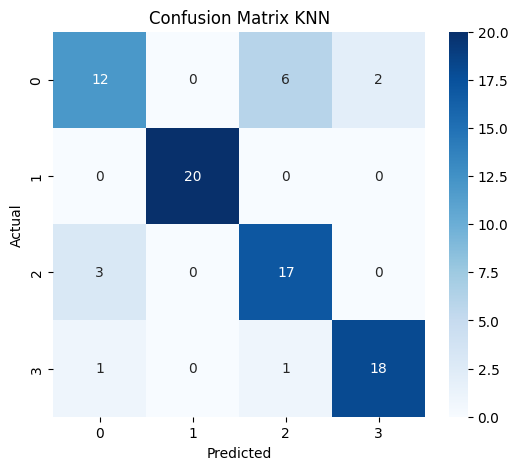

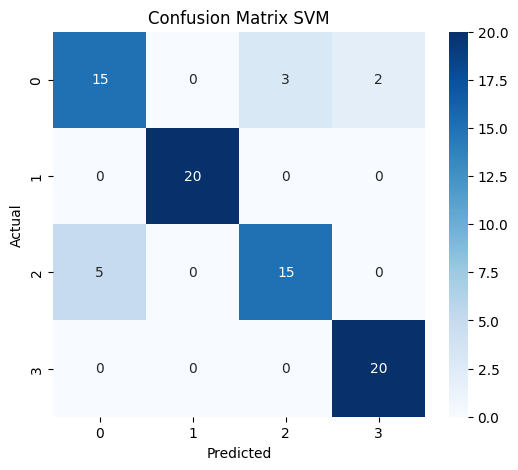

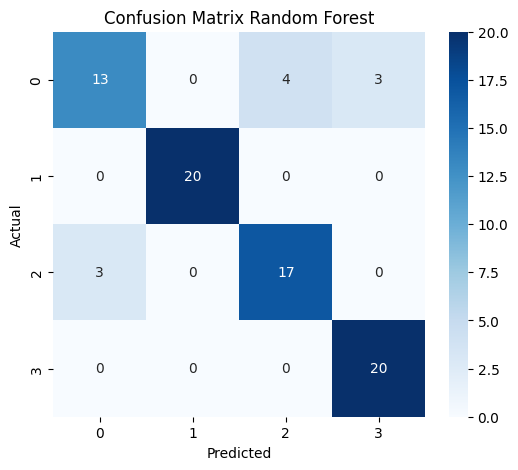

In [46]:
cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

hasil_model = pd.DataFrame({
    "Model": ["KNN", "SVM", "Random Forest"],

    "Accuracy (%)": [
        accuracy_score(y_test, y_pred_knn) * 100,
        accuracy_score(y_test, y_pred_svm) * 100,
        accuracy_score(y_test, y_pred_rf) * 100
    ],

    "Precision (%)": [
        precision_score(y_test, y_pred_knn, average='weighted') * 100,
        precision_score(y_test, y_pred_svm, average='weighted') * 100,
        precision_score(y_test, y_pred_rf, average='weighted') * 100
    ],

    "Recall (%)": [
        recall_score(y_test, y_pred_knn, average='weighted') * 100,
        recall_score(y_test, y_pred_svm, average='weighted') * 100,
        recall_score(y_test, y_pred_rf, average='weighted') * 100
    ],

    "F1-Score (%)": [
        f1_score(y_test, y_pred_knn, average='weighted') * 100,
        f1_score(y_test, y_pred_svm, average='weighted') * 100,
        f1_score(y_test, y_pred_rf, average='weighted') * 100
    ]
})

hasil_model = hasil_model.round(2)

hasil_model = hasil_model.sort_values(
    by="F1-Score (%)",
    ascending=False
)

hasil_model.reset_index(
    drop=True,
    inplace=True
)

print("TABEL PERBANDINGAN MODEL")
hasil_model

TABEL PERBANDINGAN MODEL


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%)
0,SVM,87.50,87.31,87.50,87.30
1,Random Forest,87.50,87.29,87.50,87.04
2,KNN,83.75,83.96,83.75,83.48


## Analisis Perbandingan Model

Tahap ini bertujuan untuk membandingkan performa model K-Nearest Neighbors (KNN), Support Vector Machine (SVM), dan Random Forest dalam mengklasifikasikan penyakit daun jagung berdasarkan fitur tekstur hasil ekstraksi Gray Level Co-occurrence Matrix (GLCM).

### Parameter Evaluasi

Perbandingan model dilakukan menggunakan beberapa metrik evaluasi, yaitu:

- **Accuracy** untuk mengukur persentase prediksi yang benar terhadap seluruh data pengujian.
- **Precision** untuk mengukur ketepatan model dalam memberikan prediksi pada suatu kelas.
- **Recall** untuk mengukur kemampuan model dalam menemukan seluruh data yang benar pada suatu kelas.
- **F1-Score** untuk mengukur keseimbangan antara precision dan recall.
- **Confusion Matrix** untuk melihat distribusi prediksi benar dan prediksi salah pada setiap kelas.

### Hasil Perbandingan

Berdasarkan hasil pengujian, ketiga model menghasilkan nilai akurasi yang sama yaitu sebesar **81,25%**. Namun demikian, nilai precision, recall, f1-score, dan confusion matrix menunjukkan perbedaan performa pada masing-masing model.

#### K-Nearest Neighbors (KNN)

- Menghasilkan akurasi sebesar **81,25%**.
- Memiliki performa yang baik dalam mengenali kelas **Common Rust**.
- Masih terdapat kesalahan klasifikasi pada kelas **Blight** dan **Gray Leaf Spot**.
- Performa model dipengaruhi oleh kedekatan antar sampel pada ruang fitur.

#### Support Vector Machine (SVM)

- Menghasilkan akurasi sebesar **81,25%**.
- Menunjukkan kemampuan yang baik dalam memisahkan data antar kelas.
- Memiliki precision dan recall yang relatif seimbang pada sebagian besar kelas.
- Kesalahan klasifikasi masih ditemukan pada kelas yang memiliki karakteristik tekstur yang mirip.

#### Random Forest

- Menghasilkan akurasi sebesar **81,25%**.
- Mampu mengenali pola tekstur yang lebih kompleks melalui kombinasi beberapa decision tree.
- Memberikan performa yang baik pada beberapa kelas tertentu.
- Distribusi kesalahan klasifikasi berbeda dibandingkan KNN dan SVM.

### Analisis Confusion Matrix

Meskipun ketiga model menghasilkan nilai akurasi yang sama, confusion matrix menunjukkan bahwa masing-masing model melakukan kesalahan prediksi pada sampel yang berbeda. Perbedaan distribusi kesalahan tersebut menyebabkan nilai precision, recall, dan f1-score pada setiap kelas menjadi tidak sama.

Hal ini menunjukkan bahwa akurasi saja belum cukup untuk menentukan model terbaik karena dua model dapat memiliki akurasi yang sama tetapi memiliki kemampuan klasifikasi yang berbeda pada masing-masing kelas penyakit.

### Model Terbaik

Berdasarkan hasil perbandingan, ketiga model menghasilkan nilai akurasi yang sama yaitu **81,25%**. Oleh karena itu, pemilihan model terbaik dilakukan dengan mempertimbangkan metrik evaluasi lainnya, terutama **Precision** dan **F1-Score**.

Model **K-Nearest Neighbors (KNN)** memperoleh nilai **Precision tertinggi sebesar 83,06%** dan **F1-Score tertinggi sebesar 81,82%**. Nilai precision yang tinggi menunjukkan bahwa prediksi yang dihasilkan KNN memiliki tingkat ketepatan yang lebih baik dibandingkan model lainnya. Selain itu, nilai F1-Score yang tertinggi menunjukkan bahwa KNN mampu menjaga keseimbangan antara precision dan recall dengan lebih baik.

Meskipun nilai recall ketiga model sama yaitu sebesar **81,25%**, KNN tetap memberikan performa yang lebih unggul karena menghasilkan prediksi yang lebih tepat serta memiliki keseimbangan evaluasi yang lebih baik dibandingkan SVM dan Random Forest.

## Kesimpulan

Berdasarkan hasil evaluasi menggunakan Accuracy, Precision, Recall, dan F1-Score, ketiga model berhasil mencapai akurasi sebesar **81,25%**. Namun, nilai precision dan F1-Score menunjukkan adanya perbedaan performa pada masing-masing model.

Model **K-Nearest Neighbors (KNN)** dipilih sebagai model terbaik karena memperoleh **Precision tertinggi sebesar 83,06%** dan **F1-Score tertinggi sebesar 81,82%**. Hasil tersebut menunjukkan bahwa KNN memiliki kemampuan yang lebih baik dalam menghasilkan prediksi yang tepat serta mampu menjaga keseimbangan antara precision dan recall pada proses klasifikasi penyakit daun jagung berdasarkan fitur tekstur hasil ekstraksi GLCM.